In [1]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
assets = {
    "NIFTY": "^NSEI",
    "TCS": "TCS.NS",
    "RELIANCE": "RELIANCE.NS"
}


In [5]:
prices = yf.download(
    list(assets.values()),
         start="2024-01-01",
         end="2025-01-01"
)["Close"]

[*********************100%***********************]  3 of 3 completed


In [6]:
log_returns = np.log(prices / prices.shift(1)).dropna()

In [7]:
weights = np.array([0.5, 0.2, 0.3])

In [8]:
cov_matrix = log_returns.cov()

In [9]:
cov_matrix

Ticker,RELIANCE.NS,TCS.NS,^NSEI
Ticker,,,
RELIANCE.NS,0.000209,0.000052,0.000097
TCS.NS,0.000052,0.000177,0.000051
^NSEI,0.000097,0.000051,0.000080


In [10]:
portfolio_mean = np.dot(
    weights,
    log_returns.mean()
)
portfolio_mean

5.414841115352732e-05

In [11]:
portfolio_variance = np.dot(
    weights.T,
    np.dot(cov_matrix, weights)
)
portfolio_variance

0.00011213171704571974

In [22]:
portfolio_volatility = np.sqrt(portfolio_variance)

In [23]:
portfolio_volatility

0.010589226461159462

In [24]:
portfolio_value = 10_000_000

In [25]:
# Parametric VaR
def parametric_var(
    portfolio_value,
    portfolio_mean,
    portfolio_volatility,
    confidence_level,
    holding_period=1
):
    z_score = norm.ppf(confidence_level)
    scaled_mean = (portfolio_mean * holding_period)
    scaled_volatility = (portfolio_volatility * np.sqrt(holding_period))
    var = portfolio_value * (
        z_score * scaled_volatility
        - scaled_mean
    )

    return var

In [28]:
var_95 = parametric_var(
    portfolio_value,
    portfolio_mean,
    portfolio_volatility,
    0.95,
    1
)
var_99 = parametric_var(
    portfolio_value,
    portfolio_mean,
    portfolio_volatility,
    0.99,
    1
)


In [30]:
# 10 days VaR
var_95_10days = parametric_var(
    portfolio_value,
    portfolio_mean,
    portfolio_volatility,
    0.95,
    10
)
var_99_10days = parametric_var(
    portfolio_value,
    portfolio_mean,
    portfolio_volatility,
    0.99,
    10
)


In [34]:
print(f"Porfolio Value:{portfolio_value:,.0f}")

print(f"1-day VaR 95% Confidence:{var_95:,.0f}")
print(f"1-day Var 99% Confidence:{var_99:,.0f}")
print()

print(f"10-days VaR 95% Confidence:{var_95_10days:,.0f}")
print(f"10-days VaR 99% Confidence:{var_99_10days:,.0f}")

Porfolio Value:10,000,000
1-day VaR 95% Confidence:545,382
1-day Var 99% Confidence:773,588

10-days VaR 95% Confidence:545,382
10-days VaR 99% Confidence:773,588


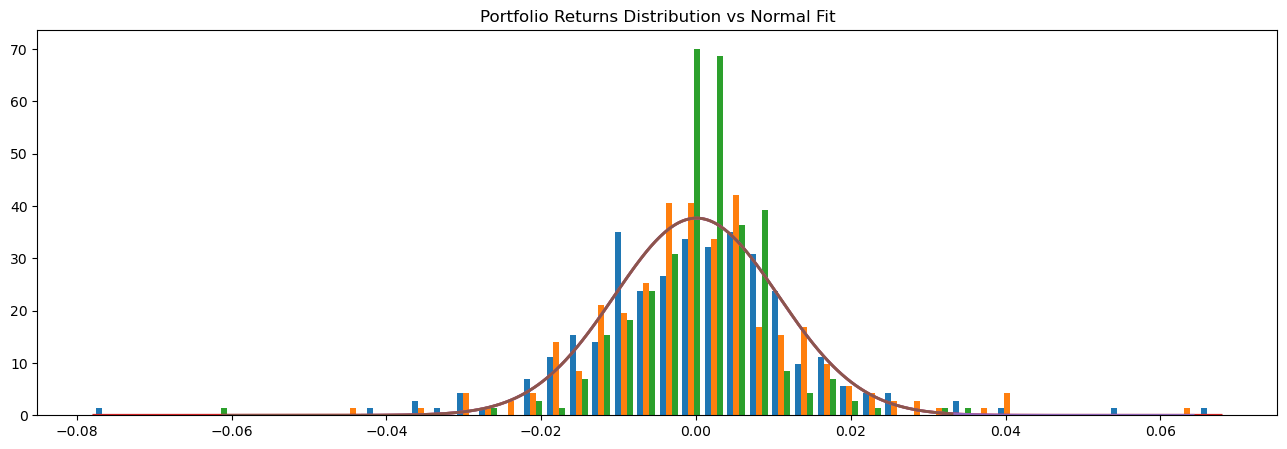

In [36]:
# plotting 
plt.figure(figsize=(16,5))

plt.hist(
    log_returns,
    bins=50,
    density = True
)

x = np.linspace(
    log_returns.min(),
    log_returns.max(),
    500
)

pdf = norm.pdf(
    x,
    portfolio_mean,
    portfolio_volatilty,
)

plt.plot(
    x,
    pdf,
    linewidth=2
)

plt.title("Portfolio Returns Distribution vs Normal Fit")
plt.show()